In [ ]:
import pandas as pd

lca_data = pd.read_csv("lca_data_bachelor_v3.csv") #Save lca_data from the R code, and import into Python

In [69]:
# Create a list of feature names excluding 'class', 'PUMFID', 'WTPF'
features = [col for col in lca_data.columns if col not in ['class', 'PUMFID', 'WTPF']]

# View the result
print(features)

['LFSTATP', 'PGMCIPAP', 'PGM_P034', 'PGM_P100', 'entrepreneurship_any', 'PGM_290', 'PGM_350', 'PGM_380', 'PGM_P401', 'EDU_010', 'STULOANS', 'BEF_P140', 'BEF_160', 'PAR1GRD', 'PAR2GRD', 'GRADAGEP', 'GENDER2', 'CTZSHIPP', 'VISBMINP', 'DDIS_FL']


In [70]:
# Weighted count per class
class_dist = (
    lca_data
    .groupby('class')['WTPF']
    .sum()
    .reset_index(name='weighted_count')
)

# Weighted proportion
class_dist['proportion'] = class_dist['weighted_count'] / class_dist['weighted_count'].sum()

print(class_dist.round(3))

   class  weighted_count  proportion
0      1       48454.555       0.203
1      2       37299.053       0.156
2      3       37480.575       0.157
3      4       49749.615       0.208
4      5       66221.867       0.277


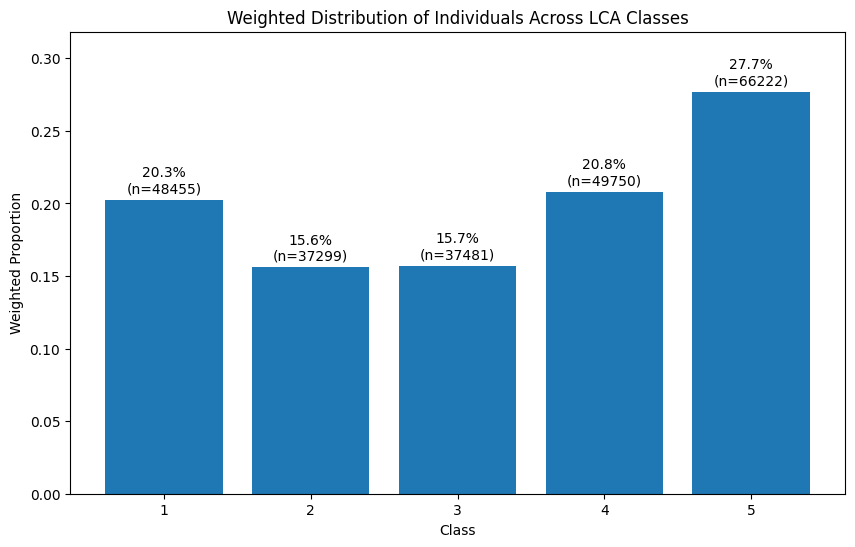

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(class_dist['class'].astype(str), class_dist['proportion'])

# Add labels
for i, row in class_dist.iterrows():
    plt.text(
        i,
        row['proportion'] + 0.005,
        f"{row['proportion']*100:.1f}%\n(n={row['weighted_count']:.0f})",
        ha='center'
    )

plt.xlabel("Class")
plt.ylabel("Weighted Proportion")
plt.title("Weighted Distribution of Individuals Across LCA Classes")

plt.ylim(0, class_dist['proportion'].max() * 1.15)
plt.show()

In [72]:
"""
feature_dict structure
----------------------
Dictionary where:
  key   = feature/variable name (string)
  value = pandas DataFrame containing weighted category proportions

DataFrame structure:
  rows    -> LCA classes (1–8)
  columns -> categories of the feature
  values  -> weighted proportion of that class in that category

Each row sums to ~1 because it represents the distribution of that
variable within the class using survey weights (WTPF).

Initialize dictionary to store matrices
"""

feature_dict = {}

# Assume features is your list of variables (excluding IDs and weights)
features = [col for col in lca_data.columns if col not in ['class', 'PUMFID', 'WTPF']]

for col in features:
    # Get all unique categories for this variable
    all_cats = lca_data[col].unique()
    
    # Compute weighted proportions per class
    weighted_prop = lca_data.groupby('class').apply(
        lambda x: pd.Series({
            cat: (x['WTPF'] * (x[col] == cat)).sum() / x['WTPF'].sum() 
            for cat in all_cats
        })
    )
    
    # Convert from long Series with MultiIndex to matrix (classes x categories)
    weighted_prop = weighted_prop.fillna(0).round(4)
    
    # If it's still a Series with MultiIndex, unstack it
    if isinstance(weighted_prop, pd.Series):
        weighted_prop = weighted_prop.unstack(level=-1).fillna(0).round(4)
    
    # Store in dictionary
    feature_dict[col] = weighted_prop

# Example checks
print(feature_dict['LFSTATP'])
print(feature_dict['entrepreneurship_any'])

            1       3       2       9
class                                
1      0.7913  0.1419  0.0665  0.0003
2      0.8909  0.0598  0.0452  0.0042
3      0.9384  0.0290  0.0323  0.0003
4      0.8306  0.0716  0.0895  0.0083
5      0.8631  0.0816  0.0550  0.0002
            2       1
class                
1      0.8306  0.1694
2      0.9014  0.0986
3      0.9407  0.0593
4      0.7955  0.2045
5      0.8092  0.1908


In [73]:
feature_dict

{'LFSTATP':             1       3       2       9
 class                                
 1      0.7913  0.1419  0.0665  0.0003
 2      0.8909  0.0598  0.0452  0.0042
 3      0.9384  0.0290  0.0323  0.0003
 4      0.8306  0.0716  0.0895  0.0083
 5      0.8631  0.0816  0.0550  0.0002,
 'PGMCIPAP':            9       1       6       8       5       2       4       7       10
 class                                                                        
 1      0.0751  0.0172  0.1361  0.1145  0.1580  0.1268  0.2999  0.0323  0.0400
 2      0.1096  0.0706  0.0176  0.0328  0.3792  0.1221  0.1869  0.0317  0.0494
 3      0.4482  0.2876  0.0000  0.1707  0.0441  0.0000  0.0130  0.0130  0.0235
 4      0.0407  0.0109  0.0640  0.1660  0.3439  0.0830  0.1308  0.1057  0.0549
 5      0.0529  0.0004  0.1086  0.0593  0.2593  0.1407  0.2888  0.0224  0.0676,
 'PGM_P034':             1       2
 class                
 1      0.8836  0.1164
 2      0.3336  0.6664
 3      0.9733  0.0267
 4      0.9293  0.0707

In [74]:
import numpy as np

prop_dict = {}
se_dict = {}

features = [col for col in lca_data.columns if col not in ['class','PUMFID','WTPF']]

for col in features:
    
    cats = lca_data[col].dropna().unique()
    
    prop_matrix = {}
    se_matrix = {}
    
    for c in sorted(lca_data['class'].unique()):
        
        subset = lca_data[lca_data['class'] == c]
        weights = subset['WTPF']
        
        # effective sample size
        n_eff = (weights.sum()**2) / (weights**2).sum()
        
        row_prop = {}
        row_se = {}
        
        for cat in cats:
            
            indicator = (subset[col] == cat).astype(int)
            
            p = np.sum(weights * indicator) / weights.sum()
            
            se = np.sqrt((p*(1-p))/n_eff)
            
            row_prop[cat] = p
            row_se[cat] = se
        
        prop_matrix[c] = row_prop
        se_matrix[c] = row_se
    
    prop_dict[col] = pd.DataFrame(prop_matrix).T
    se_dict[col] = pd.DataFrame(se_matrix).T

In [75]:
prop_dict

{'LFSTATP':           1         3         2         9
 1  0.791273  0.141928  0.066543  0.000256
 2  0.890869  0.059793  0.045167  0.004171
 3  0.938357  0.029048  0.032296  0.000299
 4  0.830607  0.071594  0.089470  0.008329
 5  0.863147  0.081645  0.055046  0.000162,
 'PGMCIPAP':          9         1         6         8         5         2         4   \
 1  0.075067  0.017225  0.136110  0.114520  0.157988  0.126819  0.299927   
 2  0.109640  0.070629  0.017600  0.032840  0.379239  0.122055  0.186899   
 3  0.448150  0.287603  0.000000  0.170660  0.044061  0.000000  0.013044   
 4  0.040741  0.010891  0.063991  0.166011  0.343931  0.082997  0.130801   
 5  0.052937  0.000413  0.108565  0.059316  0.259298  0.140671  0.288798   
 
          7         10  
 1  0.032349  0.039995  
 2  0.031727  0.049371  
 3  0.013017  0.023464  
 4  0.105747  0.054891  
 5  0.022423  0.067578  ,
 'PGM_P034':           1         2
 1  0.883581  0.116419
 2  0.333589  0.666411
 3  0.973288  0.026712
 4  0

In [76]:
se_dict

{'LFSTATP':           1         3         2         9
 1  0.015766  0.013538  0.009669  0.000621
 2  0.011538  0.008774  0.007685  0.002385
 3  0.009807  0.006848  0.007208  0.000705
 4  0.017635  0.012121  0.013419  0.004273
 5  0.011909  0.009488  0.007903  0.000441,
 'PGMCIPAP':          9         1         6         8         5         2         4   \
 1  0.010222  0.005047  0.013303  0.012354  0.014149  0.012909  0.017776   
 2  0.011561  0.009481  0.004866  0.006595  0.017954  0.012113  0.014425   
 3  0.020278  0.018457  0.000000  0.015340  0.008368  0.000000  0.004626   
 4  0.009294  0.004880  0.011506  0.017494  0.022333  0.012970  0.015853   
 5  0.007759  0.000704  0.010780  0.008185  0.015186  0.012047  0.015704   
 
          7         10  
 1  0.006864  0.007602  
 2  0.006486  0.008017  
 3  0.004622  0.006172  
 4  0.014458  0.010709  
 5  0.005130  0.008698  ,
 'PGM_P034':           1         2
 1  0.012442  0.012442
 2  0.017447  0.017447
 3  0.006575  0.006575
 4  0

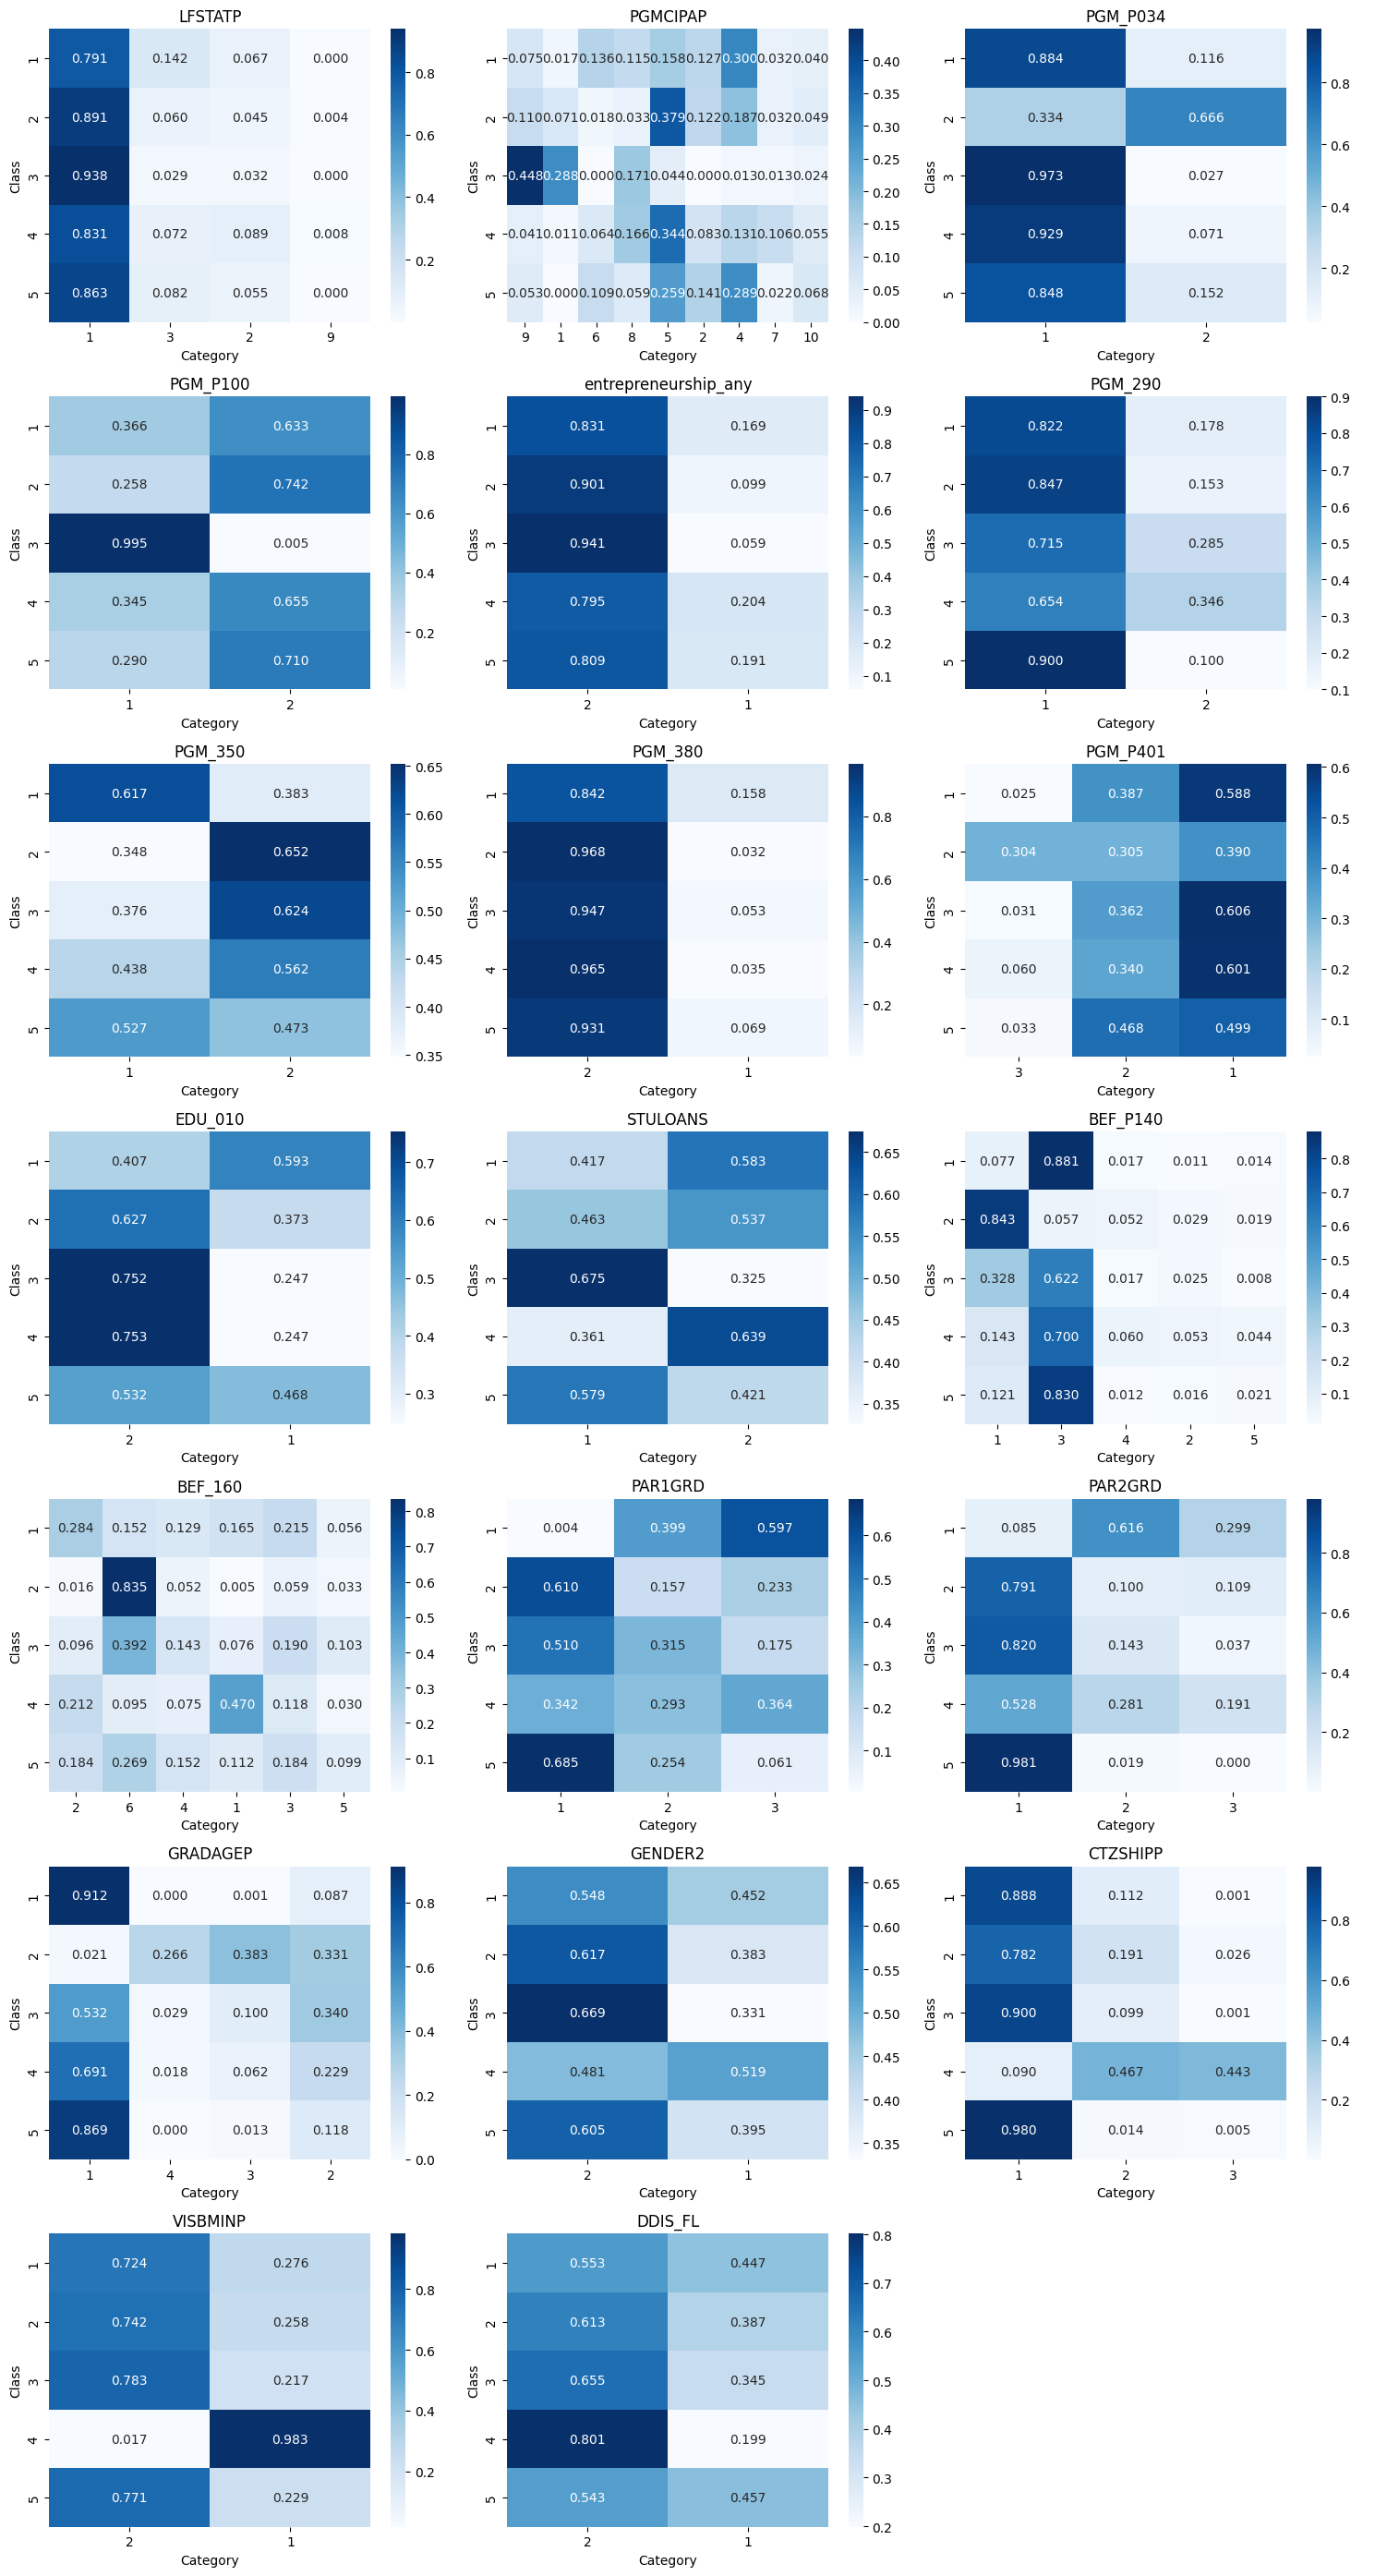

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

""" 
Heatmap of each feature of weighted proportion for each category by LCA class
"""

# Number of features
n_features = len(feature_dict)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()  # flatten to 1D array for easy iteration

for i, (feature, df) in enumerate(feature_dict.items()):
    ax = axes[i]
    sns.heatmap(df, annot=True, fmt=".3f", cmap="Blues", cbar=True, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("Category")
    ax.set_ylabel("Class")

# Hide any empty subplots if n_features < n_rows * n_cols
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [78]:
import pandas as pd

""" 
Computing how much the distribution of a categorical variable inside each LCA class differs from the overall population distribution, 
    using the survey weights (WTPF).

positive value → category is overrepresented in that class
negative value → category is underrepresented in that class
"""

# List of features (exclude IDs and weights)
features = [col for col in lca_data.columns if col not in ['class', 'PUMFID', 'WTPF']]

diff_dict = {}  # store differences for all features

for col in features:
    # Overall weighted proportion for each category
    overall_prop = (lca_data.groupby(col)['WTPF'].sum() / lca_data['WTPF'].sum())
    
    # Weighted proportion per class
    class_prop = lca_data.groupby('class').apply(
        lambda x: pd.Series({
            cat: (x['WTPF'] * (x[col] == cat)).sum() / x['WTPF'].sum()
            for cat in overall_prop.index
        })
    )
    
    # Difference from overall
    diff = class_prop.subtract(overall_prop, axis=1).round(3)
    
    diff_dict[col] = diff


for feature in diff_dict:
    print(f"Feature: {feature}")
    print(diff_dict[feature])
    print("\n")

Feature: LFSTATP
           1      2      3      9
class                            
1     -0.067  0.007  0.062 -0.002
2      0.033 -0.014 -0.020  0.002
3      0.080 -0.027 -0.051 -0.002
4     -0.027  0.030 -0.009  0.006
5      0.005 -0.004  0.002 -0.002


Feature: PGMCIPAP
          1      2      4      5      6      7      8      9      10
class                                                               
1     -0.045  0.026  0.101 -0.083  0.062 -0.009  0.009 -0.051 -0.010
2      0.009  0.021 -0.012  0.138 -0.056 -0.010 -0.073 -0.016 -0.000
3      0.226 -0.101 -0.186 -0.197 -0.074 -0.029  0.065  0.323 -0.026
4     -0.051 -0.018 -0.068  0.103 -0.010  0.064  0.060 -0.085  0.005
5     -0.062  0.040  0.090  0.018  0.035 -0.019 -0.047 -0.073  0.018


Feature: PGM_P034
           1      2
class              
1      0.072 -0.072
2     -0.478  0.478
3      0.162 -0.162
4      0.118 -0.118
5      0.037 -0.037


Feature: PGM_P100
           1      2
class              
1     -0.056  0.056
2 

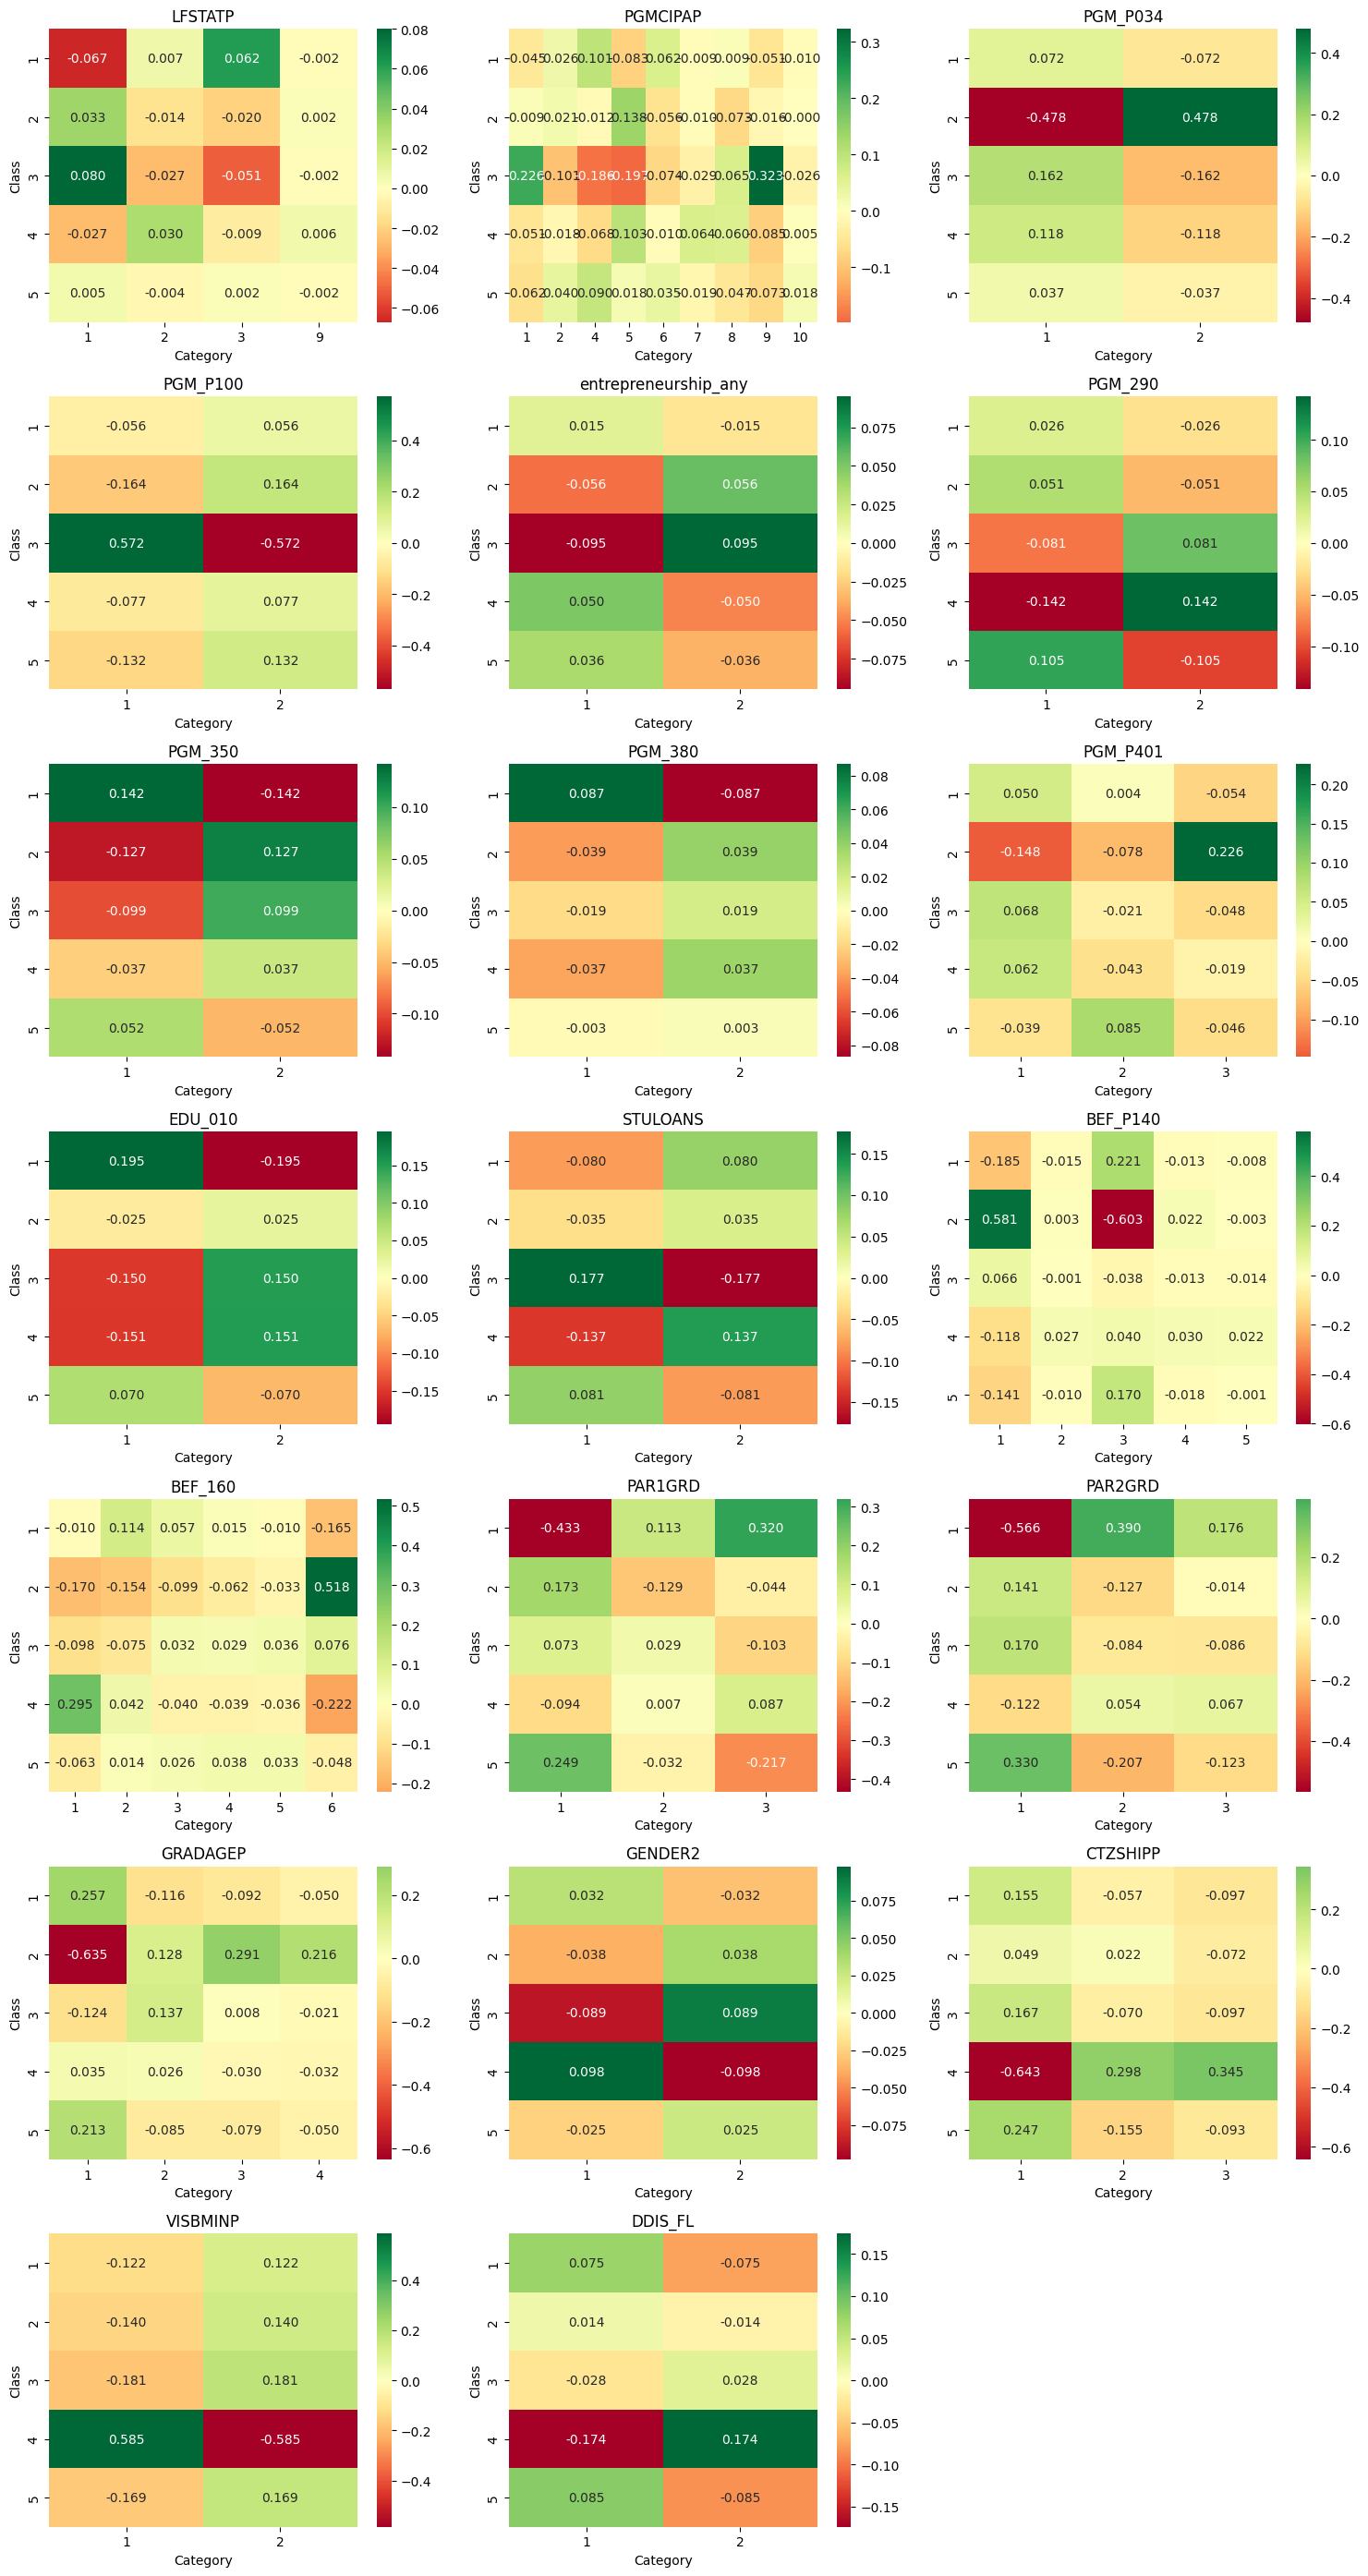

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

"""
Heatmap of each feature of weighted proportion differences by LCA class
Positive = overrepresented
Negative = underrepresented
"""


import matplotlib.pyplot as plt
import seaborn as sns

n_features = len(diff_dict)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, (feature, df) in enumerate(diff_dict.items()):
    ax = axes[i]
    
    sns.heatmap(
        df,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",   # red → white → green
        center=0,        # make 0 the white midpoint
        cbar=True,
        ax=ax
    )
    
    ax.set_title(feature)
    ax.set_xlabel("Category")
    ax.set_ylabel("Class")

# hide empty plots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [80]:
import pandas as pd

""" 
Finding the most common category for each class per variable.
Exporting table as csv.
"""

rows = []

# Use the same feature order as the heatmap
feature_order = list(diff_dict.keys())

for feature in feature_order:
    
    df = feature_dict[feature]   # weighted proportions table
    
    for cls in df.index:
        
        most_common_category = df.loc[cls].idxmax()
        weighted_prop = df.loc[cls, most_common_category]
        
        rows.append({
            "class": cls,
            "feature": feature,
            "most_common_category": most_common_category,
            "weighted_proportion": weighted_prop
        })

result_df = pd.DataFrame(rows)

# Preserve order in CSV
result_df["feature"] = pd.Categorical(result_df["feature"], categories=feature_order, ordered=True)
result_df = result_df.sort_values(["class", "feature"])

# Export
result_df.to_csv("lca_most_common_weighted_categories_by_class.csv", index=False)

print(result_df.head())

    class               feature  most_common_category  weighted_proportion
0       1               LFSTATP                     1               0.7913
5       1              PGMCIPAP                     4               0.2999
10      1              PGM_P034                     1               0.8836
15      1              PGM_P100                     2               0.6335
20      1  entrepreneurship_any                     2               0.8306


## Results/Visualizations for Report

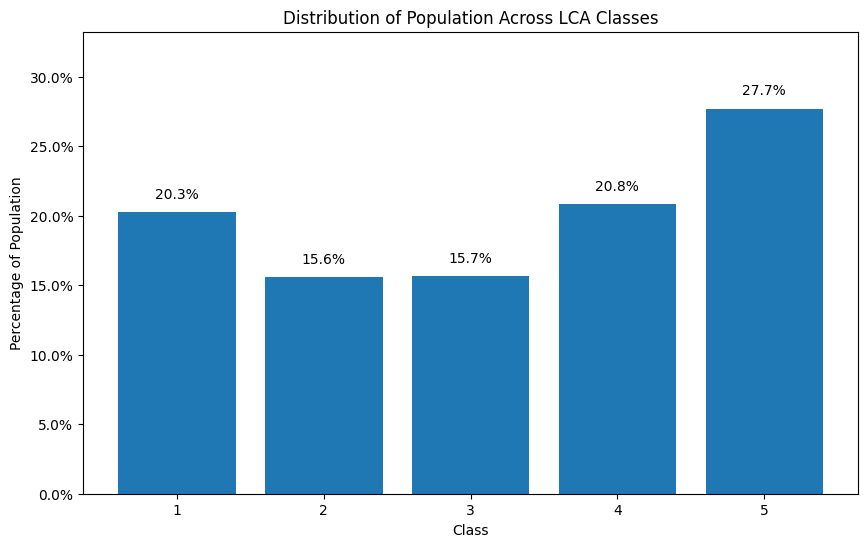

In [81]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(10,6))

# Plot bars using percentage
bars = plt.bar(class_dist['class'].astype(str), class_dist['proportion']*100)

# Add labels above bars (percentage only)
for i, row in class_dist.iterrows():
    plt.text(
        i,
        row['proportion']*100 + 1,  # slightly above the bar
        f"{row['proportion']*100:.1f}%",
        ha='center'
    )

plt.xlabel("Class")
plt.ylabel("Percentage of Population")
plt.title("Distribution of Population Across LCA Classes")

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(PercentFormatter())

plt.ylim(0, class_dist['proportion'].max()*120)  # leave some headroom
plt.show()

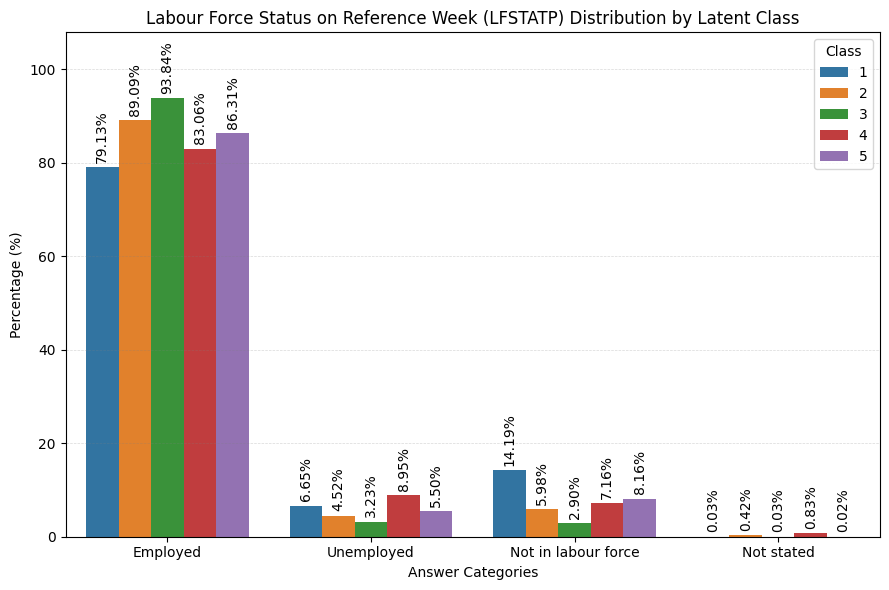

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract LFSTATP data
df = feature_dict["LFSTATP"].copy()

# Convert to long format
df_long = df.reset_index().melt(
    id_vars="class",
    var_name="category",
    value_name="proportion"
)

# Convert to percentage
df_long["percentage"] = df_long["proportion"] * 100

# Optional: nicer labels
category_labels = {
    1: "Employed",
    2: "Unemployed",
    3: "Not in labour force",
    9: "Not stated"
}

df_long["category_label"] = df_long["category"].map(category_labels)

# Ensure x-axis is in numeric order of original categories
category_order = [1, 2, 3, 9]
df_long["category_label"] = pd.Categorical(
    df_long["category_label"],
    categories=[category_labels[i] for i in category_order],
    ordered=True
)

# Distinct colors (extend or adjust if more classes)
palette = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c",
    4: "#d62728",
    5: "#9467bd"
}

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=df_long,
    x="category_label",
    y="percentage",
    hue="class",
    palette=palette,
    order=[category_labels[i] for i in category_order]  # ensure order is preserved
)

# Increase space above bars for labels
ax.set_ylim(0, df_long["percentage"].max() * 1.15)

# Add faint horizontal gridlines
ax.grid(
    axis='y',
    color='gray',
    linestyle='--',
    linewidth=0.5,
    alpha=0.3
)

# Add percentage labels (vertical)
for container in ax.containers:
    labels = [f"{v.get_height():.2f}%" for v in container]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        rotation=90
    )

plt.xlabel("Answer Categories")
plt.ylabel("Percentage (%)")
plt.title("Labour Force Status on Reference Week (LFSTATP) Distribution by Latent Class")

plt.legend(title="Class")

plt.tight_layout()
plt.show()

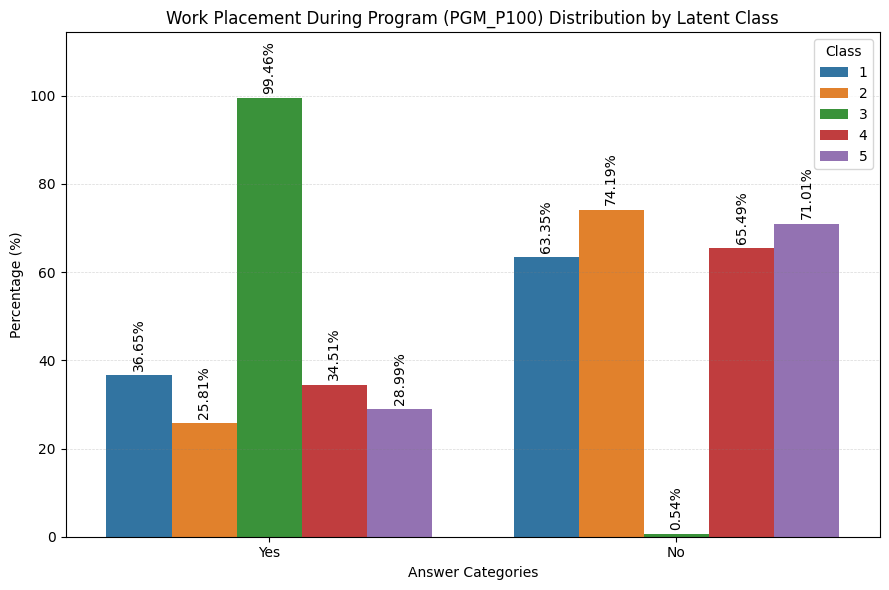

In [102]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract PGM_P100 data
df = feature_dict["PGM_P100"].copy()

# Convert to long format
df_long = df.reset_index().melt(
    id_vars="class",
    var_name="category",
    value_name="proportion"
)

# Convert to percentage
df_long["percentage"] = df_long["proportion"] * 100

# Optional: nicer labels
category_labels = {
    1: "Yes",
    2: "No",
}

df_long["category_label"] = df_long["category"].map(category_labels)

# Ensure x-axis is in numeric order of original categories
category_order = [1, 2]
df_long["category_label"] = pd.Categorical(
    df_long["category_label"],
    categories=[category_labels[i] for i in category_order],
    ordered=True
)

# Distinct colors (extend or adjust if more classes)
palette = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c",
    4: "#d62728",
    5: "#9467bd"
}

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=df_long,
    x="category_label",
    y="percentage",
    hue="class",
    palette=palette,
    order=[category_labels[i] for i in category_order]  # ensure order is preserved
)

# Increase space above bars for labels
ax.set_ylim(0, df_long["percentage"].max() * 1.15)

# Add faint horizontal gridlines
ax.grid(
    axis='y',
    color='gray',
    linestyle='--',
    linewidth=0.5,
    alpha=0.3
)

# Add percentage labels (vertical)
for container in ax.containers:
    labels = [f"{v.get_height():.2f}%" for v in container]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        rotation=90
    )

plt.xlabel("Answer Categories")
plt.ylabel("Percentage (%)")
plt.title("Work Placement During Program (PGM_P100) Distribution by Latent Class")

plt.legend(title="Class")

plt.tight_layout()
plt.show()

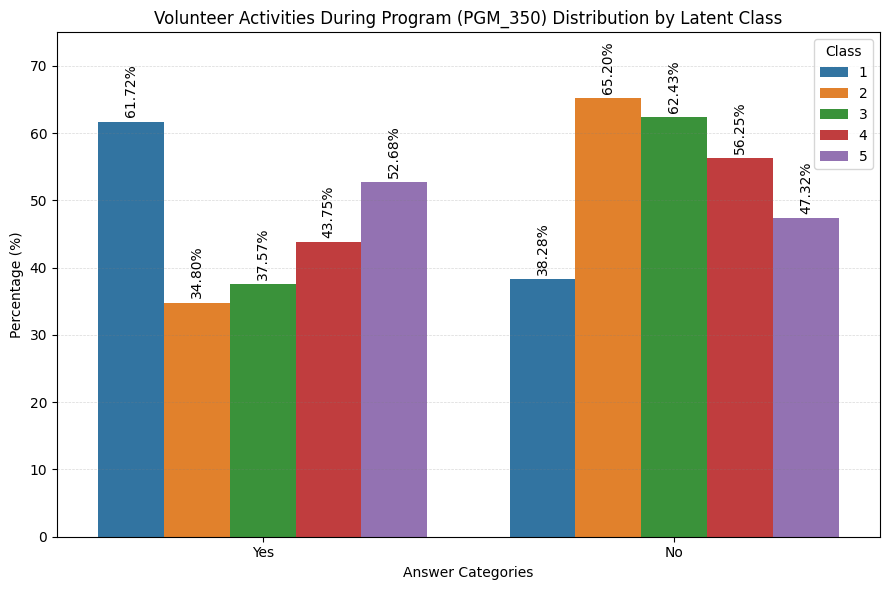

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract PGM_350 data
df = feature_dict["PGM_350"].copy()

# Convert to long format
df_long = df.reset_index().melt(
    id_vars="class",
    var_name="category",
    value_name="proportion"
)

# Convert to percentage
df_long["percentage"] = df_long["proportion"] * 100

# Optional: nicer labels
category_labels = {
    1: "Yes",
    2: "No",
}

df_long["category_label"] = df_long["category"].map(category_labels)

# Ensure x-axis is in numeric order of original categories
category_order = [1, 2]
df_long["category_label"] = pd.Categorical(
    df_long["category_label"],
    categories=[category_labels[i] for i in category_order],
    ordered=True
)

# Distinct colors (extend or adjust if more classes)
palette = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c",
    4: "#d62728",
    5: "#9467bd"
}

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=df_long,
    x="category_label",
    y="percentage",
    hue="class",
    palette=palette,
    order=[category_labels[i] for i in category_order]  # ensure order is preserved
)

# Increase space above bars for labels
ax.set_ylim(0, df_long["percentage"].max() * 1.15)

# Add faint horizontal gridlines
ax.grid(
    axis='y',
    color='gray',
    linestyle='--',
    linewidth=0.5,
    alpha=0.3
)

# Add percentage labels (vertical)
for container in ax.containers:
    labels = [f"{v.get_height():.2f}%" for v in container]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        rotation=90
    )

plt.xlabel("Answer Categories")
plt.ylabel("Percentage (%)")
plt.title("Volunteer Activities During Program (PGM_350) Distribution by Latent Class")

plt.legend(title="Class")

plt.tight_layout()
plt.show()

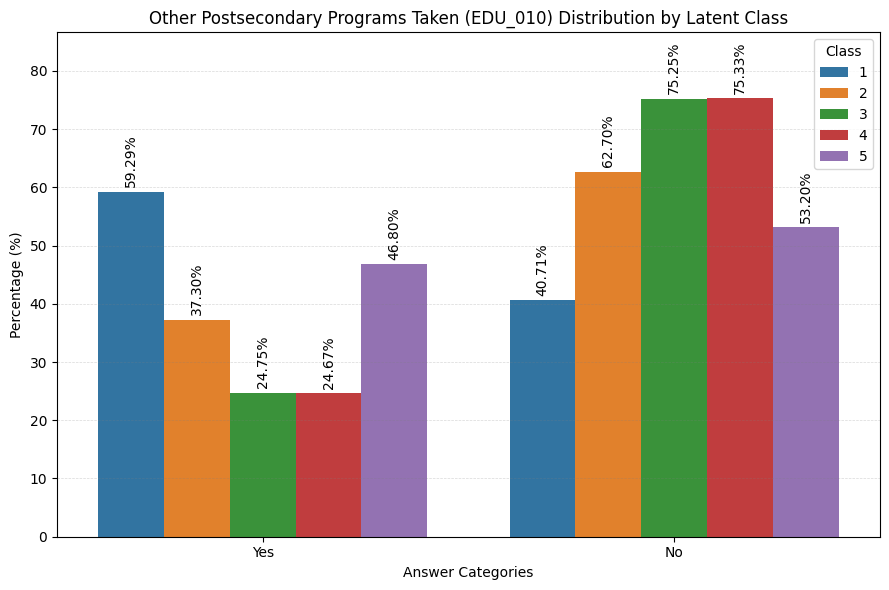

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract EDU_010 data
df = feature_dict["EDU_010"].copy()

# Convert to long format
df_long = df.reset_index().melt(
    id_vars="class",
    var_name="category",
    value_name="proportion"
)

# Convert to percentage
df_long["percentage"] = df_long["proportion"] * 100

# Optional: nicer labels
category_labels = {
    1: "Yes",
    2: "No",
}

df_long["category_label"] = df_long["category"].map(category_labels)

# Ensure x-axis is in numeric order of original categories
category_order = [1, 2]
df_long["category_label"] = pd.Categorical(
    df_long["category_label"],
    categories=[category_labels[i] for i in category_order],
    ordered=True
)

# Distinct colors (extend or adjust if more classes)
palette = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c",
    4: "#d62728",
    5: "#9467bd"
}

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=df_long,
    x="category_label",
    y="percentage",
    hue="class",
    palette=palette,
    order=[category_labels[i] for i in category_order]  # ensure order is preserved
)

# Increase space above bars for labels
ax.set_ylim(0, df_long["percentage"].max() * 1.15)

# Add faint horizontal gridlines
ax.grid(
    axis='y',
    color='gray',
    linestyle='--',
    linewidth=0.5,
    alpha=0.3
)

# Add percentage labels (vertical)
for container in ax.containers:
    labels = [f"{v.get_height():.2f}%" for v in container]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        rotation=90
    )

plt.xlabel("Answer Categories")
plt.ylabel("Percentage (%)")
plt.title("Other Postsecondary Programs Taken (EDU_010) Distribution by Latent Class")

plt.legend(title="Class")

plt.tight_layout()
plt.show()

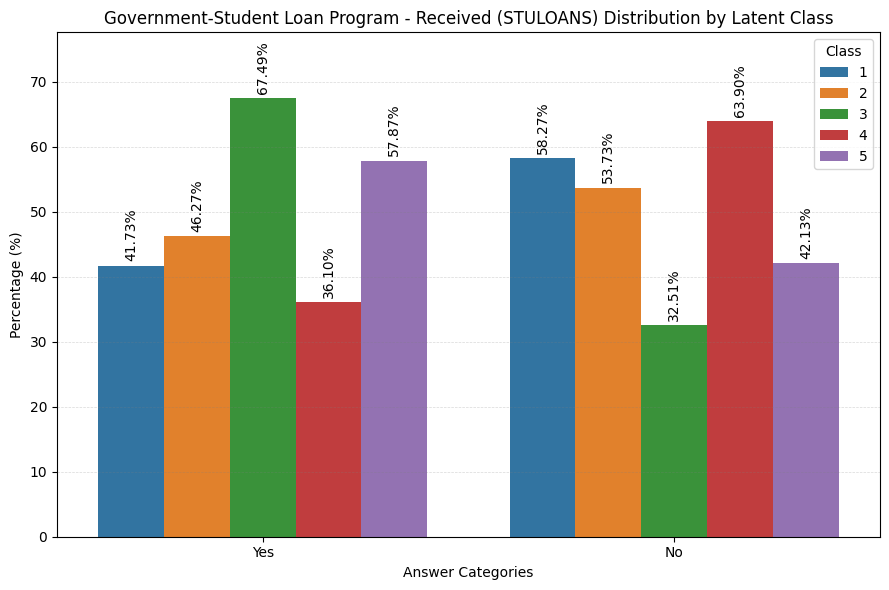

In [89]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract STULOANS data
df = feature_dict["STULOANS"].copy()

# Convert to long format
df_long = df.reset_index().melt(
    id_vars="class",
    var_name="category",
    value_name="proportion"
)

# Convert to percentage
df_long["percentage"] = df_long["proportion"] * 100

# Optional: nicer labels
category_labels = {
    1: "Yes",
    2: "No",
}

df_long["category_label"] = df_long["category"].map(category_labels)

# Ensure x-axis is in numeric order of original categories
category_order = [1, 2]
df_long["category_label"] = pd.Categorical(
    df_long["category_label"],
    categories=[category_labels[i] for i in category_order],
    ordered=True
)

# Distinct colors (extend or adjust if more classes)
palette = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c",
    4: "#d62728",
    5: "#9467bd"
}

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=df_long,
    x="category_label",
    y="percentage",
    hue="class",
    palette=palette,
    order=[category_labels[i] for i in category_order]  # ensure order is preserved
)

# Increase space above bars for labels
ax.set_ylim(0, df_long["percentage"].max() * 1.15)

# Add faint horizontal gridlines
ax.grid(
    axis='y',
    color='gray',
    linestyle='--',
    linewidth=0.5,
    alpha=0.3
)

# Add percentage labels (vertical)
for container in ax.containers:
    labels = [f"{v.get_height():.2f}%" for v in container]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        rotation=90
    )

plt.xlabel("Answer Categories")
plt.ylabel("Percentage (%)")
plt.title("Government-Student Loan Program - Received (STULOANS) Distribution by Latent Class")

plt.legend(title="Class")

plt.tight_layout()
plt.show()

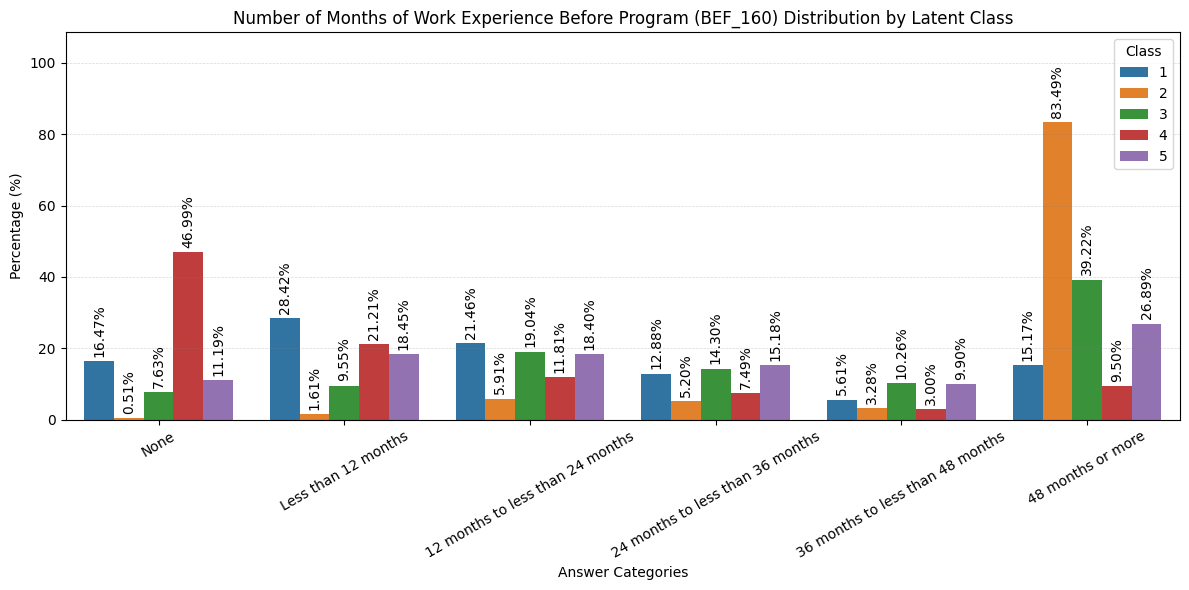

In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract BEF_160 data
df = feature_dict["BEF_160"].copy()

# Convert to long format
df_long = df.reset_index().melt(
    id_vars="class",
    var_name="category",
    value_name="proportion"
)

# Convert to percentage
df_long["percentage"] = df_long["proportion"] * 100

# Optional: nicer labels
category_labels = {
    1: "None",
    2: "Less than 12 months",
    3: "12 months to less than 24 months",
    4: "24 months to less than 36 months",
    5: "36 months to less than 48 months",
    6: "48 months or more",
}

df_long["category_label"] = df_long["category"].map(category_labels)

# Ensure x-axis is in numeric order of original categories
category_order = [1,2,3,4,5,6]
df_long["category_label"] = pd.Categorical(
    df_long["category_label"],
    categories=[category_labels[i] for i in category_order],
    ordered=True
)

# Distinct colors (extend or adjust if more classes)
palette = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c",
    4: "#d62728",
    5: "#9467bd"
}

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=df_long,
    x="category_label",
    y="percentage",
    hue="class",
    palette=palette,
    order=[category_labels[i] for i in category_order]  # ensure order is preserved
)

# Increase space above bars for labels
ax.set_ylim(0, df_long["percentage"].max() * 1.30)

# Add faint horizontal gridlines
ax.grid(
    axis='y',
    color='gray',
    linestyle='--',
    linewidth=0.5,
    alpha=0.3
)

# Add percentage labels (vertical)
for container in ax.containers:
    labels = [f"{v.get_height():.2f}%" for v in container]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        rotation=90
    )

plt.xticks(rotation=30)

plt.xlabel("Answer Categories")
plt.ylabel("Percentage (%)")
plt.title("Number of Months of Work Experience Before Program (BEF_160) Distribution by Latent Class")

plt.legend(title="Class")

plt.tight_layout()
plt.show()

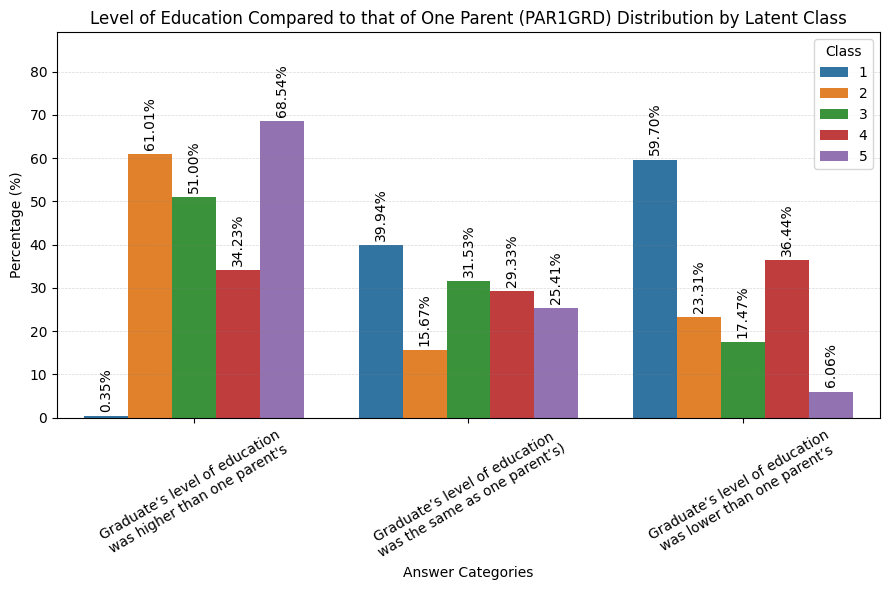

In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract PAR1GRD data
df = feature_dict["PAR1GRD"].copy()

# Convert to long format
df_long = df.reset_index().melt(
    id_vars="class",
    var_name="category",
    value_name="proportion"
)

# Convert to percentage
df_long["percentage"] = df_long["proportion"] * 100

# Optional: nicer labels
category_labels = {
    1: "Graduate’s level of education\nwas higher than one parent's",
    2: "Graduate’s level of education\nwas the same as one parent’s)",
    3: "Graduate’s level of education\nwas lower than one parent’s"
}

df_long["category_label"] = df_long["category"].map(category_labels)

# Ensure x-axis is in numeric order of original categories
category_order = [1, 2, 3]
df_long["category_label"] = pd.Categorical(
    df_long["category_label"],
    categories=[category_labels[i] for i in category_order],
    ordered=True
)

# Distinct colors (extend or adjust if more classes)
palette = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c",
    4: "#d62728",
    5: "#9467bd"
}

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=df_long,
    x="category_label",
    y="percentage",
    hue="class",
    palette=palette,
    order=[category_labels[i] for i in category_order]  # ensure order is preserved
)

# Increase space above bars for labels
ax.set_ylim(0, df_long["percentage"].max() * 1.30)

# Add faint horizontal gridlines
ax.grid(
    axis='y',
    color='gray',
    linestyle='--',
    linewidth=0.5,
    alpha=0.3
)

# Add percentage labels (vertical)
for container in ax.containers:
    labels = [f"{v.get_height():.2f}%" for v in container]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        rotation=90
    )

plt.xticks(rotation=30)

plt.xlabel("Answer Categories")
plt.ylabel("Percentage (%)")
plt.title("Level of Education Compared to that of One Parent (PAR1GRD) Distribution by Latent Class")

plt.legend(title="Class")

plt.tight_layout()
plt.show()

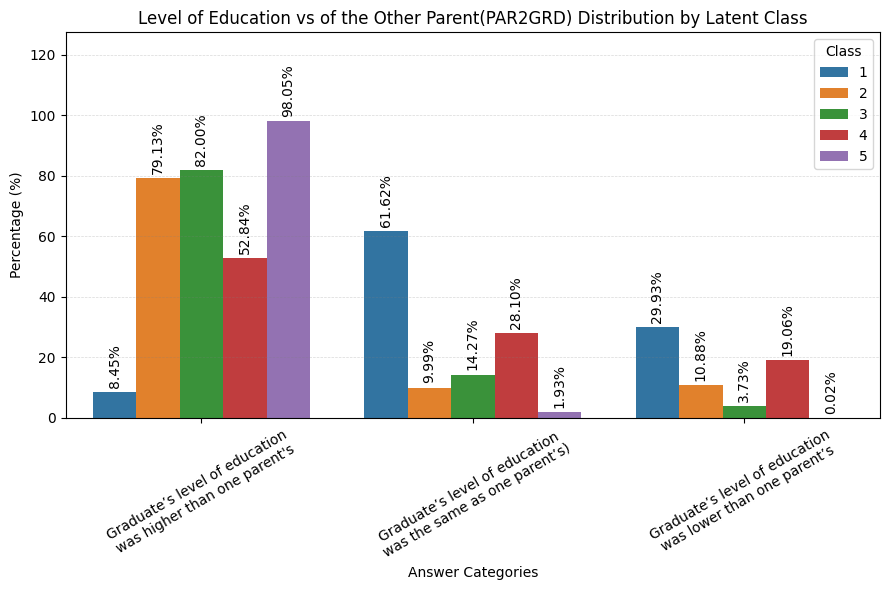

In [101]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract PAR2GRD data
df = feature_dict["PAR2GRD"].copy()

# Convert to long format
df_long = df.reset_index().melt(
    id_vars="class",
    var_name="category",
    value_name="proportion"
)

# Convert to percentage
df_long["percentage"] = df_long["proportion"] * 100

# Optional: nicer labels
category_labels = {
    1: "Graduate’s level of education\nwas higher than one parent's",
    2: "Graduate’s level of education\nwas the same as one parent’s)",
    3: "Graduate’s level of education\nwas lower than one parent’s"
}

df_long["category_label"] = df_long["category"].map(category_labels)

# Ensure x-axis is in numeric order of original categories
category_order = [1, 2, 3]
df_long["category_label"] = pd.Categorical(
    df_long["category_label"],
    categories=[category_labels[i] for i in category_order],
    ordered=True
)

# Distinct colors (extend or adjust if more classes)
palette = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#2ca02c",
    4: "#d62728",
    5: "#9467bd"
}

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=df_long,
    x="category_label",
    y="percentage",
    hue="class",
    palette=palette,
    order=[category_labels[i] for i in category_order]  # ensure order is preserved
)

# Increase space above bars for labels
ax.set_ylim(0, df_long["percentage"].max() * 1.30)

# Add faint horizontal gridlines
ax.grid(
    axis='y',
    color='gray',
    linestyle='--',
    linewidth=0.5,
    alpha=0.3
)

# Add percentage labels (vertical)
for container in ax.containers:
    labels = [f"{v.get_height():.2f}%" for v in container]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        rotation=90
    )

plt.xticks(rotation=30)

plt.xlabel("Answer Categories")
plt.ylabel("Percentage (%)")
plt.title("Level of Education vs of the Other Parent(PAR2GRD) Distribution by Latent Class")

plt.legend(title="Class")

plt.tight_layout()
plt.show()